In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
import ast

sns.set_theme(style="whitegrid")

print("Bắt đầu đọc và xử lý các tệp CSV...")

try:
    nodes_df = pd.read_csv('data/nodes.csv')
    edges_df = pd.read_csv('data/edges.csv')
    edges_df['los'] = edges_df['los'].apply(ast.literal_eval)
    edges_df['weight'] = edges_df['weight'].apply(ast.literal_eval)
except FileNotFoundError as e:
    print(f"\nKhông tìm thấy tệp '{e.filename}'.")

print("==================================================")
print(" Phân tích tệp: nodes.csv")
print("==================================================")
print("\n(1) 5 dòng dữ liệu đầu tiên:")
display(nodes_df.head())

print(f"\n(2) Tổng số hàng: {len(nodes_df):,}")

print("\n(3) Thông tin cơ bản (.info()):")
nodes_df.info(memory_usage='deep')

print("\n(4) Số lượng giá trị rỗng mỗi cột:")
print(nodes_df.isnull().sum())
print("\n")

print("==================================================")
print(" Phân tích tệp: edges.csv")
print("==================================================")
print("\n(1) 5 dòng dữ liệu đầu tiên:")
display(edges_df.head())

print(f"\n(2) Tổng số hàng: {len(edges_df):,}")

print("\n(3) Thông tin cơ bản (.info()):")
edges_df.info(memory_usage='deep')

print("\n(4) Số lượng giá trị rỗng mỗi cột:")
print(edges_df.isnull().sum())

Bắt đầu đọc và xử lý các tệp CSV...
 Phân tích tệp: nodes.csv

(1) 5 dòng dữ liệu đầu tiên:


,osmid,y,x
0,11393695758,10.786110,106.700575
1,5762711597,10.768145,106.689217
2,5762711598,10.768457,106.687108
3,3506700347,10.769955,106.694330
4,8359904042,10.776721,106.692342



(2) Tổng số hàng: 3,151

(3) Thông tin cơ bản (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3151 entries, 0 to 3150
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   osmid   3151 non-null   int64  
 1   y       3151 non-null   float64
 2   x       3151 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 74.0 KB

(4) Số lượng giá trị rỗng mỗi cột:
osmid    0
y        0
x        0
dtype: int64


 Phân tích tệp: edges.csv

(1) 5 dòng dữ liệu đầu tiên:


,u,v,osmid,length,geometry,los,weight
0,11393695758,13513813140,308848875,36.227606,"LINESTRING (106.700575 10.7861099, 106.7008135...","[1.15, 1.15, 1.15, 1.15, 1.151, 1.152, 1.156, ...","[41.662, 41.662, 41.662, 41.662, 41.698, 41.73..."
1,11393695758,6110770486,308848875,101.498002,"LINESTRING (106.700575 10.7861099, 106.6999068...","[1.0, 1.0, 1.0, 1.0, 1.001, 1.002, 1.006, 1.01...","[101.498, 101.498, 101.498, 101.498, 101.6, 10..."
2,5762711598,4600569893,1173914714,47.953805,"LINESTRING (106.6871076 10.7684571, 106.687411...","[1.15, 1.15, 1.15, 1.15, 1.151, 1.152, 1.156, ...","[55.147, 55.147, 55.147, 55.147, 55.195, 55.24..."
3,5762711598,4605034952,1173914714,15.614007,"LINESTRING (106.6871076 10.7684571, 106.687054...","[1.15, 1.15, 1.15, 1.15, 1.151, 1.152, 1.156, ...","[17.956, 17.956, 17.956, 17.956, 17.972, 17.98..."
4,3506700347,2527488815,723841572,27.624147,"LINESTRING (106.6943304 10.7699546, 106.694269...","[1.15, 1.15, 1.15, 1.15, 1.151, 1.152, 1.156, ...","[31.768, 31.768, 31.768, 31.768, 31.795, 31.82..."



(2) Tổng số hàng: 5,643

(3) Thông tin cơ bản (.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5643 entries, 0 to 5642
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u         5643 non-null   int64  
 1   v         5643 non-null   int64  
 2   osmid     5643 non-null   int64  
 3   length    5643 non-null   float64
 4   geometry  5643 non-null   object 
 5   los       5643 non-null   object 
 6   weight    5643 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 6.0 MB

(4) Số lượng giá trị rỗng mỗi cột:
u           0
v           0
osmid       0
length      0
geometry    0
los         0
weight      0
dtype: int64


Phân tích Không gian (Spatial Analysis): Kiểm tra Hình thái Mạng lưới
Trước khi chạy thuật toán, ta cần vẽ thử tọa độ của các nút giao (Nodes) lên trục 2D để đảm bảo dữ liệu không bị lỗi tọa độ và mạng lưới đường bộ khớp với khu vực trung tâm TP.HCM.

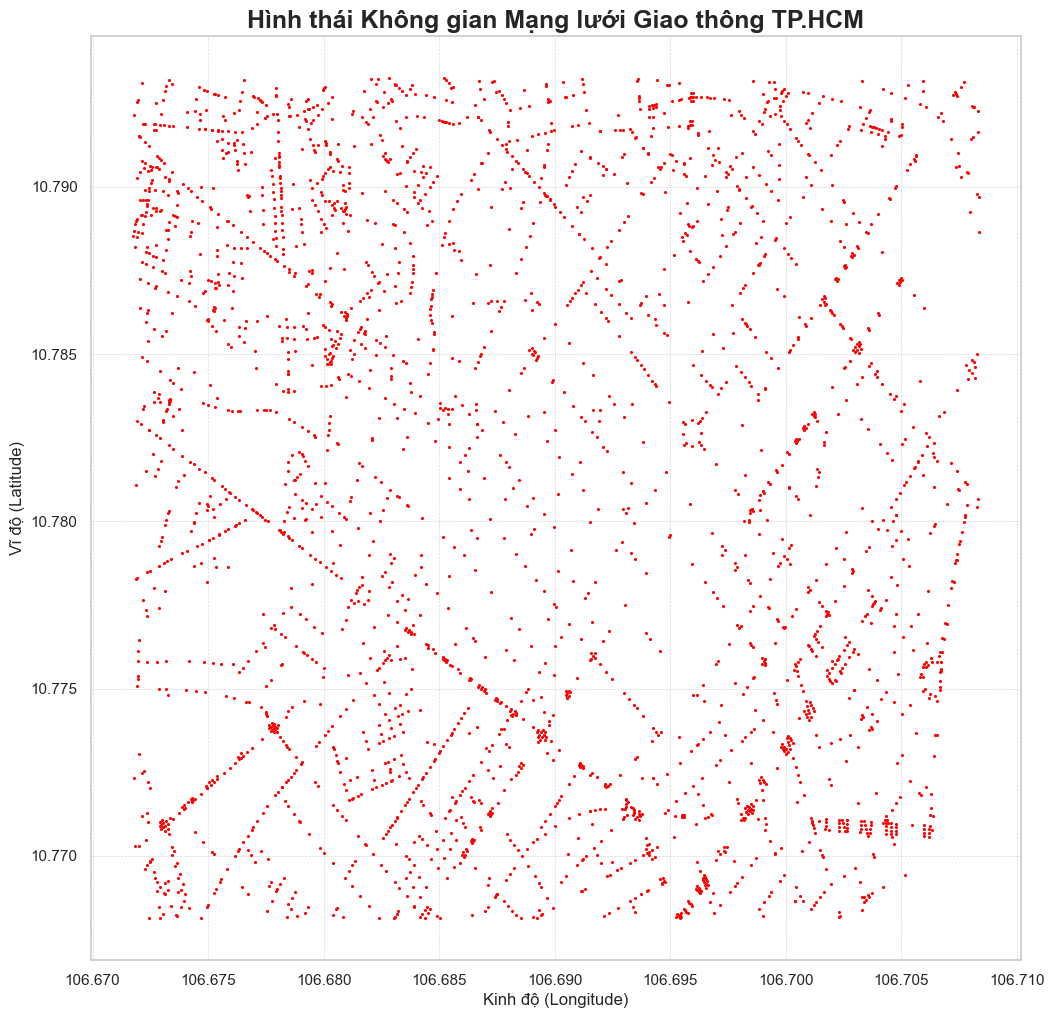

In [6]:
# Thiết lập kích thước biểu đồ
plt.figure(figsize=(12, 12))

# Vẽ đồ thị phân tán (Scatter Plot) với x là Kinh độ, y là Vĩ độ
plt.scatter(nodes_df['x'], nodes_df['y'], s=1.5, c='red', alpha=1)

plt.title('Hình thái Không gian Mạng lưới Giao thông TP.HCM', fontsize=18, fontweight='bold')
plt.xlabel('Kinh độ (Longitude)', fontsize=12)
plt.ylabel('Vĩ độ (Latitude)', fontsize=12)

# Chỉnh nền tối cho biểu đồ để các điểm xanh nổi bật hơn
plt.gca().set_facecolor("#ffffff")
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.show()

Mỗi đoạn đường có một mảng `los` gồm 48 phần tử tương ứng với 48 khung giờ trong ngày (mỗi 30 phút). Ta sẽ tính trung bình mức độ kẹt xe của TOÀN BỘ các đoạn đường trong từng khung giờ để tìm ra quy luật "Giờ cao điểm".